In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

In [2]:
url= "https://realpython.github.io/fake-jobs/"
response=requests.get(url)
print(response.status_code)

200


In [3]:
soup= BeautifulSoup(response.text, "html.parser")

In [7]:
jobs= soup.find_all("div",class_="card-content")
len(jobs)

100

In [8]:
titles=[]
companies=[]
locations=[]

In [9]:
for job in jobs:
    
    title=job.find("h2").text.strip()
    company=job.find("h3").text.strip()
    location=job.find("p",class_="location").text.strip()
    
    titles.append(title)
    companies.append(company)
    locations.append(location)

In [13]:
df= pd.DataFrame({
    "Job Title": titles,
    "Company": companies,
    "Location": locations
})
df.head

<bound method NDFrame.head of                              Job Title                     Company  \
0              Senior Python Developer    Payne, Roberts and Davis   
1                      Energy engineer            Vasquez-Davidson   
2                      Legal executive  Jackson, Chambers and Levy   
3               Fitness centre manager              Savage-Bradley   
4                      Product manager                 Ramirez Inc   
..                                 ...                         ...   
95  Museum/gallery exhibitions officer     Nguyen, Yoder and Petty   
96            Radiographer, diagnostic                  Holder LLC   
97              Database administrator              Yates-Ferguson   
98                  Furniture designer             Ortega-Lawrence   
99                         Ship broker   Fuentes, Walls and Castro   

                Location  
0        Stewartbury, AA  
1   Christopherville, AA  
2    Port Ericaburgh, AA  
3      East Seanview,

In [15]:
df.to_csv("../data/jobs.csv",index=False)

In [16]:
len(jobs)

100

In [17]:
import sqlite3

In [18]:
conn= sqlite3.connect("../data/jobs.db")

In [19]:
df.to_sql("jobs",conn,if_exists="replace",index=False)

100

In [20]:
query="SELECT * FROM jobs LIMIT 5"

pd.read_sql(query,conn)

,Job Title,Company,Location
0,Senior Python Developer,"Payne, Roberts and Davis","Stewartbury, AA"
1,Energy engineer,Vasquez-Davidson,"Christopherville, AA"
2,Legal executive,"Jackson, Chambers and Levy","Port Ericaburgh, AA"
3,Fitness centre manager,Savage-Bradley,"East Seanview, AP"
4,Product manager,Ramirez Inc,"North Jamieview, AP"


In [28]:
query = """
SELECT "Job Title", COUNT(*) as total
FROM jobs
GROUP BY "Job Title"
ORDER BY total DESC
LIMIT 10
"""

pd.read_sql(query, conn)

,Job Title,total
0,Python Programmer (Entry-Level),3
1,Software Developer (Python),2
2,Materials engineer,2
3,Manufacturing systems engineer,2
4,Legal executive,2
5,Futures trader,2
6,"Back-End Web Developer (Python, Django)",2
7,Writer,1
8,Waste management officer,1
9,Warden/ranger,1


In [27]:

query="""
SELECT Company,Count(*) as total_jobs
FROM jobs
GROUP BY Company
ORDER BY total_jobs DESC
LIMIT 10
"""

pd.read_sql(query,conn)

,Company,total_jobs
0,Garcia PLC,2
1,Yates-Ferguson,1
2,Wood Inc,1
3,"Williams, Peterson and Rojas",1
4,"Waters, Wilson and Hoover",1
5,Washington-Castillo,1
6,Washington PLC,1
7,Walker-Simpson,1
8,Vasquez-Davidson,1
9,Vasquez Ltd,1


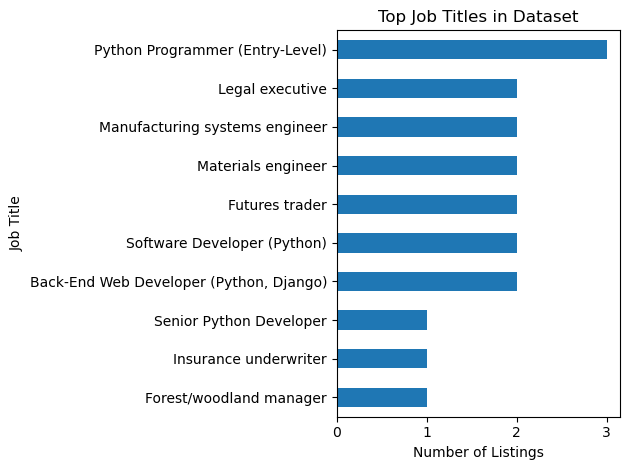

<Figure size 640x480 with 0 Axes>

In [55]:
import matplotlib.pyplot as plt

top_jobs= df["Job Title"].value_counts().head(10)[::-1]
top_jobs.plot(kind="barh")
plt.title("Top Job Titles in Dataset")
plt.ylabel("Job Title")
plt.xlabel("Number of Listings")

plt.tight_layout()

plt.show()
plt.savefig("../images/top_job_titles.png")

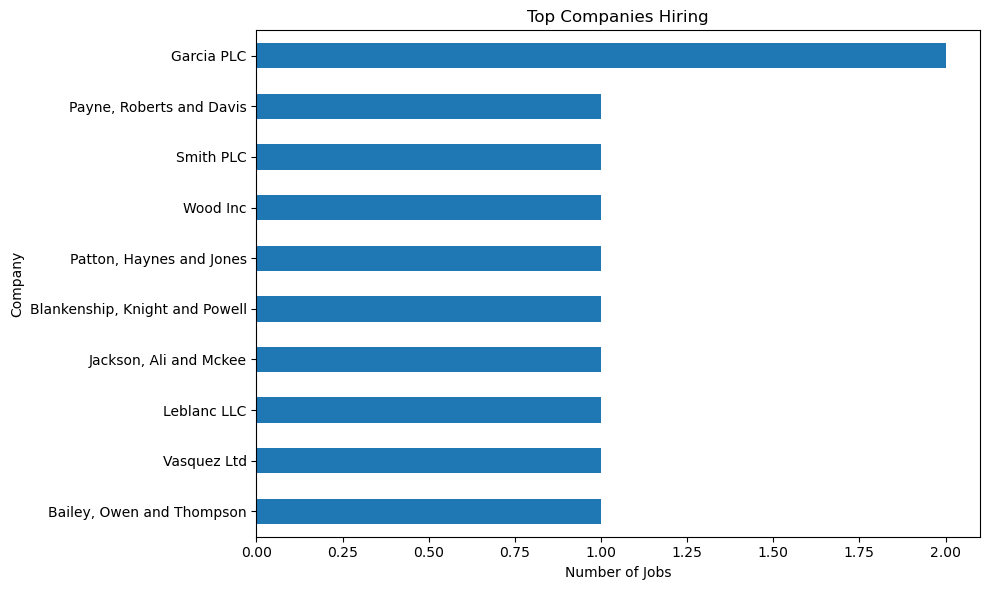

<Figure size 640x480 with 0 Axes>

In [54]:

plt.figure(figsize=(10,6))
top_companies= df["Company"].value_counts().head(10)[::-1]

top_companies.plot(kind="barh")
plt.title("Top Companies Hiring")
plt.ylabel("Company")
plt.xlabel("Number of Jobs")
plt.tight_layout()
plt.show()
plt.savefig("../images/top_companies_hiring.png")

In [58]:
df["Python Job"]=df["Job Title"].str.contains("Python",case=False)

In [59]:
df.head()

,Job Title,Company,Location,Python Job
0,Senior Python Developer,"Payne, Roberts and Davis","Stewartbury, AA",True
1,Energy engineer,Vasquez-Davidson,"Christopherville, AA",False
2,Legal executive,"Jackson, Chambers and Levy","Port Ericaburgh, AA",False
3,Fitness centre manager,Savage-Bradley,"East Seanview, AP",False
4,Product manager,Ramirez Inc,"North Jamieview, AP",False


In [61]:
df["Python Job"].value_counts()

False    90
True     10
Name: Python Job, dtype: int64

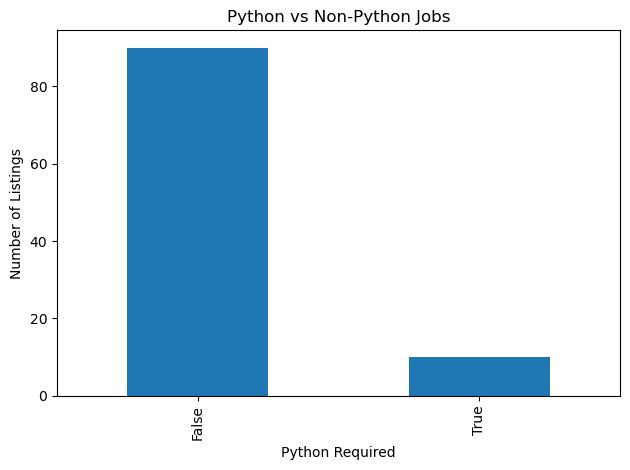

In [73]:
python_jobs=df["Python Job"].value_counts()
python_jobs.plot(kind="bar")
plt.title("Python vs Non-Python Jobs")
plt.xlabel("Python Required")
plt.ylabel("Number of Listings")
plt.tight_layout()
plt.show()


In [74]:
plt.savefig("../images/python_jobs.png")

<Figure size 640x480 with 0 Axes>

In [66]:
python_df=df[df["Python Job"]==True]
python_df

,Job Title,Company,Location,Python Job
0,Senior Python Developer,"Payne, Roberts and Davis","Stewartbury, AA",True
10,Software Engineer (Python),Garcia PLC,"Ericberg, AE",True
20,Python Programmer (Entry-Level),"Moss, Duncan and Allen","Port Sara, AE",True
30,Python Programmer (Entry-Level),Cooper and Sons,"West Victor, AE",True
40,Software Developer (Python),Adams-Brewer,"Brockburgh, AE",True
50,Python Developer,Rivera and Sons,"East Michaelfort, AA",True
60,"Back-End Web Developer (Python, Django)",Stewart-Alexander,"South Kimberly, AA",True
70,"Back-End Web Developer (Python, Django)","Jackson, Ali and Mckee","New Elizabethside, AA",True
80,Python Programmer (Entry-Level),Mathews Inc,"Robertborough, AP",True
90,Software Developer (Python),Moreno-Rodriguez,"Martinezburgh, AE",True


In [ ]:
#Python Job Percentage

In [67]:
python_percentage=df["Python Job"].mean()*100
python_percentage

10.0

In [ ]:
#Number of Unique Companies

In [68]:
df["Company"].nunique()

99

In [69]:
#Number of Unique Job Roles
df["Job Title"].nunique()

92

In [70]:
#Most Frequent Role

In [72]:
df["Job Title"].value_counts().idxmax()

'Python Programmer (Entry-Level)'